# sc2ts on simulated pathogens

How well sc2ts recovers recombinants and the overall ARG when the truth is known, for
a range of simulated pathogens. The simulations and scoring are done by the Snakemake
pipeline in `simulations/slim` (see its README); this notebook reads the combined
results it keeps in `simulations/slim/summaries/{pathogen}/`, for every pathogen
found there.

**Simulation.** For each pathogen, SLiM simulates a neutral, haploid Wright-Fisher
population that grows from a single founder to $N$ cases per generation over
`GROWTH_GENS` generations, then stays at that size up to `GENS` generations. The genome
has length $L$ and mutation rate `MU` per site per generation, and a fraction
`EFF_RECOMB` of births have two parents, with a single uniformly placed breakpoint.
Each generation is one sampling date for sc2ts. The parameters of each pathogen are in
the table below, from `simulations/slim/config.yaml`.

**Sampling and inference.** For each of the pathogen's numbers of samples per day, a
uniform random sample of that many individuals is taken from every generation (all
of it, if smaller), with the smaller samples a subset of the larger. sc2ts is run
with $k = 3, 4, 5$ and otherwise the parameters used for the Viridian ARG, except
that its time-traveller filtering is turned off: the simulated samples have exact
dates and no errors, so every sample is added on its own day. The final ARG is then
run through `sc2ts postprocess`, which adds samples identical to a node already in
the ARG ("exact matches") as nodes of their own.

**What counts as a recombinant.** A sample should be inferred to be a recombinant if it
is one itself, *or* if it inherits a recombination from an unsampled ancestor: walking
up its clonal line, it reaches a recombinant before reaching any individual placed in
the inferred ARG. Several samples can share one such recombinant ancestor; once sc2ts
has inferred that recombination in one of them, the rest correctly copy from it with
a single parent. So:

- **precision** is per sample: of the samples sc2ts matched with two parents, the
  fraction expected to be recombinants;
- **recall** is per recombination *event*: the fraction of recombinant ancestors for
  which at least one expected sample was matched with two parents.

Only samples placed in the ARG are scored.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yaml

In [2]:
slim_dir = Path("../simulations/slim")
with open(slim_dir / "config.yaml") as f:
    config = yaml.safe_load(f)

summaries_dir = slim_dir / "summaries"
pathogens = sorted(path.name for path in summaries_dir.iterdir() if path.is_dir())


def load(name):
    return pd.concat(
        [pd.read_csv(summaries_dir / pathogen / f"{name}.csv") for pathogen in pathogens]
    )


# One row per run.
summary = load("summary")
# One row per expected recombination event per run.
events = load("events")
# Samples, placed samples and exact matches per generation per run.
placement = load("placement")

k_values = sorted(summary.k.unique())
sample_sizes = {
    pathogen: sorted(summary[summary.pathogen == pathogen].samples_per_day.unique())
    for pathogen in pathogens
}
pathogens

['coronavirus']

## Pathogens

In [3]:
rows = []
for pathogen in pathogens:
    params = config["pathogens"][pathogen]
    row = dict(params["slim"])
    row["mutations_per_genome"] = row["L"] * row["MU"]
    row["samples_per_day"] = ", ".join(str(s) for s in params["samples_per_day"])
    rows.append(row)
pd.DataFrame(rows, index=pd.Index(pathogens, name="pathogen"))

,N,GENS,GROWTH_GENS,L,MU,EFF_RECOMB,mutations_per_genome,samples_per_day
pathogen,,,,,,,,
coronavirus,1000,100,20,30000,0.000012,0.01,0.36,"20, 100"


In [4]:
# k and the number of samples per day are both ordered, so each is one hue
# stepped light to dark.
k_colors = dict(zip(k_values, ["#86b6ef", "#2a78d6", "#104281"]))
BLUE_RAMP = ["#86b6ef", "#5598e7", "#256abf", "#104281"]


def s_colors(pathogen):
    values = sample_sizes[pathogen]
    steps = np.linspace(0, len(BLUE_RAMP) - 1, len(values)).round().astype(int)
    return dict(zip(values, [BLUE_RAMP[j] for j in steps]))


grid_kwargs = dict(color="0.9", linewidth=0.6)

# The median breakpoint interval in the Viridian ARG, from the paper.
PAPER_MEDIAN_INTERVAL = 2018


def clean_axes(ax):
    ax.yaxis.grid(True, **grid_kwargs)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

## Summary

`exact_matches` is the number of samples added by `sc2ts postprocess`, `held_back` the
number sc2ts never added. `sampled` is the number of samples that are recombinants
themselves, `expected` the number that should be inferred to be recombinants, and
`events` the number of distinct recombinant ancestors behind them.

In [5]:
table = summary.set_index(["pathogen", "samples_per_day", "k"])[
    [
        "num_samples",
        "num_placed",
        "num_exact_matches",
        "num_held_back",
        "num_sampled_recombinants",
        "num_expected_recombinants",
        "num_events",
        "num_inferred_recombinants",
        "false_positives",
        "precision",
        "events_detected",
        "recall",
        "recall_detectable",
        "breakpoint_in_interval",
    ]
].rename(
    columns=lambda c: c.replace("num_", "").replace("_recombinants", "")
)
table.round(3)

samples  placed  exact_matches  held_back  \
pathogen    samples_per_day k                                              
coronavirus 20              3     1892    1892            274          0   
                            4     1892    1892            274          0   
                            5     1892    1892            274          0   
            100             3     9003    9003           2730          0   
                            4     9003    9003           2728          0   
                            5     9003    9003           2728          0   

                               sampled  expected  events  inferred  \
pathogen    samples_per_day k                                        
coronavirus 20              3       19       327     154       101   
                            4       19       327     154        84   
                            5       19       327     154        77   
            100             3       85       690     326       240   
                            4       85       690     326       199   
                            5       85       690     326       178   

                               false_positives  precision  events_detected  \
pathogen    samples_per_day k                                                
coronavirus 20              3                6      0.941               92   
                            4                1      0.988               80   
                            5                1      0.987               74   
            100             3               10      0.958              220   
                            4                1      0.995              189   
                            5                0      1.000              169   

                               recall  recall_detectable  \
pathogen    samples_per_day k                              
coronavirus 20              3   0.597              0.636   
                            4   0.519              0.559   
                            5   0.481              0.517   
            100             3   0.675              0.728   
                            4   0.580              0.625   
                            5   0.518              0.558   

                               breakpoint_in_interval  
pathogen    samples_per_day k                          
coronavirus 20              3                   0.901  
                            4                   0.924  
                            5                   0.905  
            100             3                   0.982  
                            4                   0.979  
                            5                   0.970

## Precision and recall

Raising $k$ trades recall for precision, as on the real data.

**coronavirus.** Precision is high throughout (0.94 to 1): almost every sample sc2ts
reports as a recombinant really does carry an unrepresented recombination. Recall falls
from 0.6-0.7 at $k = 3$ to about 0.5 at $k = 5$, and is a little higher with 100
samples per day than with 20.

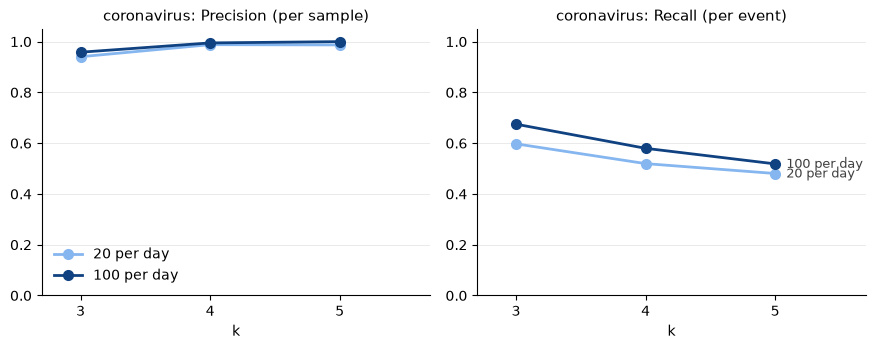

In [6]:
fig, axes = plt.subplots(
    len(pathogens), 2, figsize=(9, 3.6 * len(pathogens)), sharex=True, squeeze=False
)
for row, pathogen in zip(axes, pathogens):
    colors = s_colors(pathogen)
    for ax, column, title in zip(
        row, ["precision", "recall"], ["Precision (per sample)", "Recall (per event)"]
    ):
        for s in sample_sizes[pathogen]:
            df = summary[
                (summary.pathogen == pathogen) & (summary.samples_per_day == s)
            ].sort_values("k")
            ax.plot(
                df.k, df[column], marker="o", markersize=7, linewidth=2,
                color=colors[s], label=f"{s} per day",
            )
            # Precision lines sit too close together to label directly.
            if column == "recall":
                ax.annotate(
                    f"{s} per day", xy=(df.k.iloc[-1], df[column].iloc[-1]),
                    xytext=(8, 0), textcoords="offset points", va="center",
                    fontsize=9, color="0.25",
                )
        ax.set_title(f"{pathogen}: {title}", fontsize=11)
        ax.set_xticks(k_values)
        ax.set_ylim(0, 1.05)
        ax.set_xlim(k_values[0] - 0.3, k_values[-1] + 0.7)
        clean_axes(ax)
    row[0].legend(frameon=False, loc="lower left")
for ax in axes[-1]:
    ax.set_xlabel("k")
fig.tight_layout()

## Which events are found

Detectable events (where the recombinant differs from both its parents; the rest leave
no trace), split by whether the recombinant itself was sampled and placed, or is only
seen through its descendants.

**coronavirus.** Most events are only seen through descendants, and sc2ts finds those
at least as well as recombinants that were themselves sampled.

In [7]:
events["kind"] = np.where(events.sampled, "recombinant sampled", "descendants only")
(
    events[events.detectable]
    .groupby(["pathogen", "samples_per_day", "k", "kind"])
    .detected.agg(["size", "mean"])
    .rename(columns={"size": "events", "mean": "recall"})
    .unstack("kind")
    .round(3)
)

events                      \
kind                          descendants only recombinant sampled   
pathogen    samples_per_day k                                        
coronavirus 20              3              126                  17   
                            4              126                  17   
                            5              126                  17   
            100             3              230                  71   
                            4              230                  71   
                            5              230                  71   

                                        recall                      
kind                          descendants only recombinant sampled  
pathogen    samples_per_day k                                       
coronavirus 20              3            0.667               0.412  
                            4            0.579               0.412  
                            5            0.532               0.412  
            100             3            0.752               0.648  
                            4            0.648               0.549  
                            5            0.587               0.465

## Exact matches

A sample identical to a node already in the ARG is not given a node of its own during
inference, only counted against the node it matches; `sc2ts postprocess` adds these
exact matches as nodes under that node.

**coronavirus.** With about 0.36 mutations per genome per generation, many samples are
identical to a sampled relative: 15% of samples with 20 per day and 30% with 100 per
day.

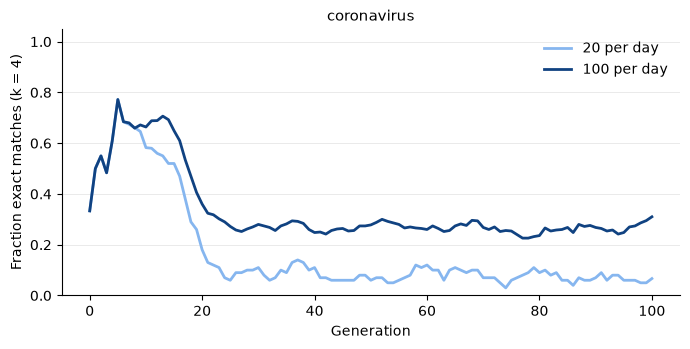

In [8]:
fig, axes = plt.subplots(
    len(pathogens), 1, figsize=(7, 3.6 * len(pathogens)), squeeze=False
)
for ax, pathogen in zip(axes[:, 0], pathogens):
    colors = s_colors(pathogen)
    for s in sample_sizes[pathogen]:
        df = placement[
            (placement.pathogen == pathogen)
            & (placement.samples_per_day == s)
            & (placement.k == 4)
        ].set_index("gen")
        rate = df.num_exact_matches / df.num_samples
        # Smooth over 5 generations: there are few samples per generation at low S.
        smooth = rate.rolling(5, center=True, min_periods=1).mean()
        ax.plot(
            smooth.index, smooth.values, linewidth=2, color=colors[s], label=f"{s} per day"
        )
    ax.set_title(pathogen, fontsize=11)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fraction exact matches (k = 4)")
    ax.set_ylim(0, 1.05)
    ax.legend(frameon=False)
    clean_axes(ax)
fig.tight_layout()

In [9]:
df = placement[placement.k == 4].groupby(["pathogen", "samples_per_day"])[
    ["num_samples", "num_exact_matches"]
].sum()
(df.num_exact_matches / df.num_samples).round(3)

pathogen     samples_per_day
coronavirus  20                 0.145
             100                0.303
dtype: float64

## Breakpoints

Breakpoint intervals run from the last site supporting the left parent to the first
supporting the right. For events found with a single breakpoint, taking the earliest
sample the event was found in, we compare the interval with the true breakpoint, and
its width with the median in the real Viridian ARG (dashed line, 2,018 bases).

**coronavirus.** The true breakpoint falls in the interval 97-98% of the time with 100
samples per day and 90-92% with 20. Interval widths are of the same order as in the
real ARG (medians of about 1,250-1,550 bases), as expected with a similar per-genome
mutation rate.

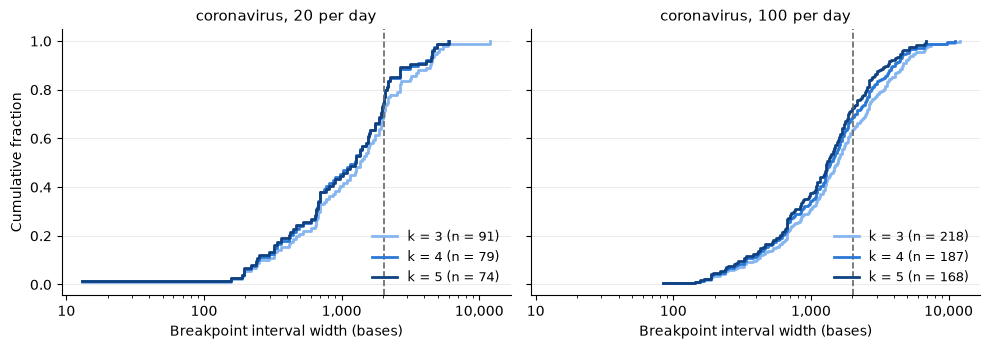

In [10]:
# Events found with a single breakpoint have an interval.
found = events.dropna(subset=["interval_width"])

num_columns = max(len(values) for values in sample_sizes.values())
fig, axes = plt.subplots(
    len(pathogens), num_columns, figsize=(5 * num_columns, 3.6 * len(pathogens)),
    sharex=True, sharey=True, squeeze=False,
)
for row, pathogen in zip(axes, pathogens):
    for ax in row[len(sample_sizes[pathogen]):]:
        ax.set_visible(False)
    for ax, s in zip(row, sample_sizes[pathogen]):
        for k in k_values:
            df = found[
                (found.pathogen == pathogen) & (found.samples_per_day == s) & (found.k == k)
            ]
            width = np.sort(df.interval_width.values)
            ax.step(
                width, np.arange(1, len(width) + 1) / len(width), where="post",
                linewidth=2, color=k_colors[k], label=f"k = {k} (n = {len(width)})",
            )
        ax.axvline(PAPER_MEDIAN_INTERVAL, color="0.4", linestyle="--", linewidth=1.2)
        ax.set_title(f"{pathogen}, {s} per day", fontsize=11)
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
        ax.xaxis.set_minor_formatter(mticker.NullFormatter())
        ax.legend(frameon=False, loc="lower right", fontsize=9)
        clean_axes(ax)
    row[0].set_ylabel("Cumulative fraction")
for ax in axes[-1]:
    ax.set_xlabel("Breakpoint interval width (bases)")
fig.tight_layout()

In [11]:
found.groupby(["pathogen", "samples_per_day", "k"]).interval_width.median()

pathogen     samples_per_day  k
coronavirus  20               3    1367.0
                              4    1244.0
                              5    1254.0
             100              3    1560.5
                              4    1377.0
                              5    1309.0
Name: interval_width, dtype: float64

## ARG accuracy

`tscompare.haplotype_arf(inferred, true)`, over all placed samples. `arf` is the
fraction of the inferred ARG's node span not found in the true ARG, `tpr` the fraction
of the true ARG's span found in the inferred one, and `rmse` the error in log node
times (in generations) of matched nodes.

**coronavirus.** Accuracy is lower with 100 samples per day than with 20, which is down
to the exact matches: identical sequences carry no information about how they are
related, and sc2ts places them all directly under the node they match, while the true
genealogy among them is resolved. Leaving the exact matches out of the comparison
(checked for $k = 4$, outside this notebook) gives an ARF of 0.168 and TPR of 0.629
with 100 per day, and 0.167 and 0.639 with 20: almost the same.

In [12]:
summary.set_index(["pathogen", "samples_per_day", "k"])[["arf", "tpr", "rmse"]].round(3)

arf    tpr   rmse
pathogen    samples_per_day k                     
coronavirus 20              3  0.201  0.619  0.093
                            4  0.202  0.621  0.091
                            5  0.205  0.620  0.092
            100             3  0.237  0.589  0.061
                            4  0.237  0.589  0.061
                            5  0.238  0.589  0.061

## Notes

- ARF and TPR barely change with $k$. Recombination is rare enough in these
  simulations that the clonal topology dominates the node-span comparison, so these
  measure tree accuracy more than recombinant accuracy, and at high sampling density
  they are dominated by how exact matches are placed.
- **coronavirus.** Turning off sc2ts's time-traveller filtering made the biggest
  difference at low sampling density: in an earlier run with the Viridian settings
  (`hmm_cost_threshold` 7) and about 20 samples per day, 39% of samples were held
  back and never added, and recall was only 0.41, 0.31 and 0.17 for $k = 3, 4, 5$.
  With every sample added, recall with 20 per day is close to that with 100.
  Precision is high at every $k$; the few false positives (at most 10 in a run) are
  worth looking at individually.
- One replicate per pathogen so far: no uncertainty estimates yet.